# Frequency Decoding — Neurosoft Minipigs 2026

Minimal example: load a single session, extract fixed-length windows using
torch_brain's `SequentialFixedWindowSampler`, and train a logistic regression
on the **acoustic_stim** multiclass task (7 stimulation frequencies, intrasession split).

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import scipy.signal as sps
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

from torch_brain.data.sampler import SequentialFixedWindowSampler

from auditorydecoding.datasets.neurosoft_minipigs_2026.NeurosoftMinipgs2026 import (
    NeurosoftMinipigs2026,
)

In [3]:
DATA_ROOT = "../data/processed"
RECORDING_ID = "sub-02_ses-01_task-AcousticStim_desc-raw_LH"

WINDOW_LENGTH = 0.5  # seconds
FOLD_NUM = 0
SPLIT_TYPE = "intrasession"
TASK_TYPE = "acoustic_stim"
BALANCE_CLASSES = True

In [4]:
dataset = NeurosoftMinipigs2026(
    root=DATA_ROOT,
    recording_ids=[RECORDING_ID],
    fold_num=FOLD_NUM,
    split_type=SPLIT_TYPE,
    task_type=TASK_TYPE,
)

print(f"Recording IDs: {dataset.recording_ids}")

for split in ("train", "valid", "test"):
    intervals = dataset.get_sampling_intervals(split=split)
    for rid, iv in intervals.items():
        n = len(iv.start)
        dur = sum(iv.end - iv.start)
        labels, counts = np.unique(iv.behavior_labels, return_counts=True)
        dist = ", ".join(f"{l}: {c}" for l, c in zip(labels, counts))
        print(f"  {split:>5s}: {n:4d} intervals, {dur:6.1f}s  {{ {dist} }}")

Recording IDs: ['sub-02_ses-01_task-AcousticStim_desc-raw_LH']
  train:  672 intervals,  336.0s  { stim_10000Hz: 63, stim_1000Hz: 64, stim_15000Hz: 72, stim_20000Hz: 64, stim_2000Hz: 140, stim_5000Hz: 174, stim_500Hz: 95 }
  valid:  168 intervals,   84.0s  { stim_10000Hz: 16, stim_1000Hz: 16, stim_15000Hz: 18, stim_20000Hz: 16, stim_2000Hz: 35, stim_5000Hz: 43, stim_500Hz: 24 }
   test:  420 intervals,  210.0s  { stim_10000Hz: 40, stim_1000Hz: 39, stim_15000Hz: 45, stim_20000Hz: 40, stim_2000Hz: 88, stim_5000Hz: 109, stim_500Hz: 59 }


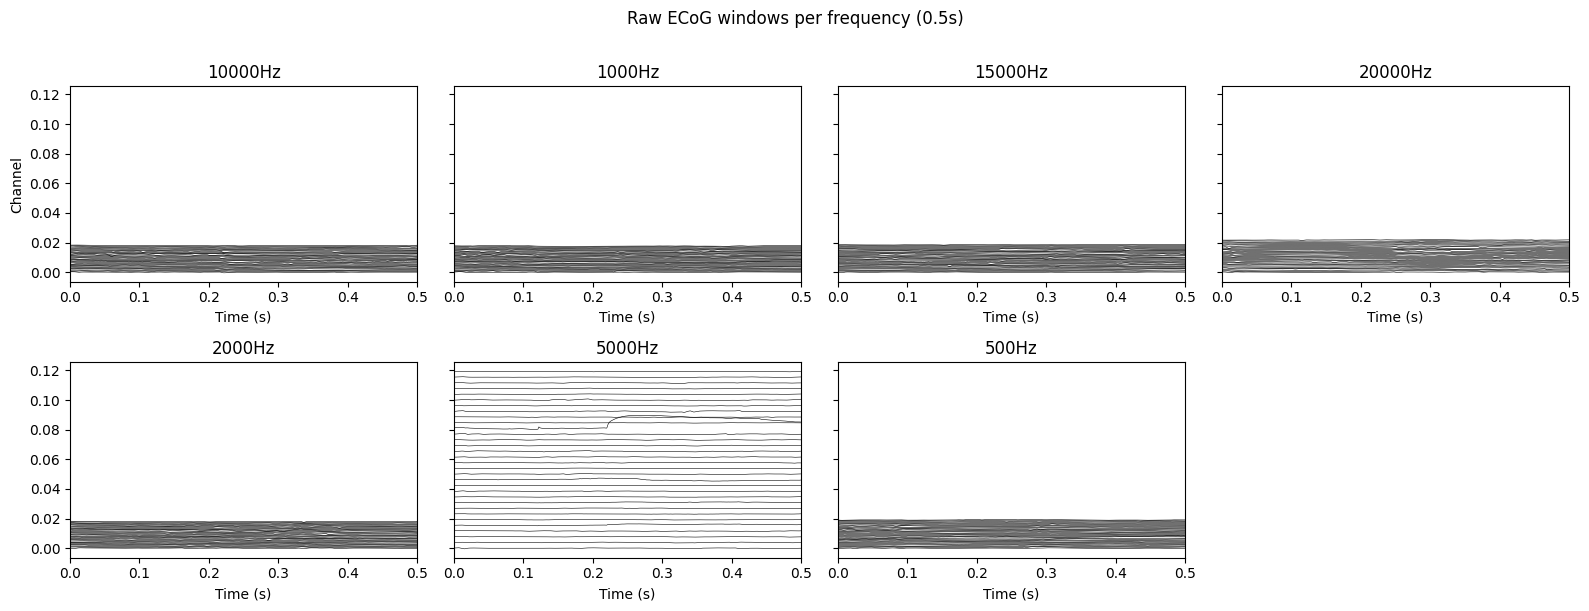

In [5]:
train_intervals = dataset.get_sampling_intervals(split="train")
rid = dataset.recording_ids[0]
intervals = train_intervals[rid]
unique_labels = sorted(set(intervals.behavior_labels))

n_cols = 4
n_rows = (len(unique_labels) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows), sharey=True)
axes = axes.flatten()

for ax, freq_label in zip(axes, unique_labels):
    idx = np.where(intervals.behavior_labels == freq_label)[0][0]
    start = intervals.start[idx]
    sample = dataset.get_recording(rid).slice(start, start + WINDOW_LENGTH)
    signal = sample.ecog.signal
    t = np.arange(signal.shape[0]) / (signal.shape[0] / WINDOW_LENGTH)

    spacing = 4 * np.std(signal)
    for ch in range(signal.shape[1]):
        ax.plot(t, signal[:, ch] + ch * spacing, linewidth=0.4, color="k")

    ax.set_title(freq_label.replace("stim_", ""))
    ax.set_xlabel("Time (s)")
    ax.set_xlim(0, WINDOW_LENGTH)

for ax in axes[len(unique_labels):]:
    ax.set_visible(False)

axes[0].set_ylabel("Channel")
fig.suptitle(f"Raw ECoG windows per frequency ({WINDOW_LENGTH}s)", y=1.01)
fig.tight_layout()
plt.show()

In [6]:
def extract_features(signal, mode="mean", n_samples=None):
    """Convert a (n_timepoints, n_channels) signal window into a flat feature vector.

    Modes
    -----
    "mean"     : channel-wise mean              -> (n_channels,)
    "signal"   : flatten raw signal             -> (n_timepoints * n_channels,)
    "resample" : resample then flatten          -> (n_samples * n_channels,)
    "fft"      : rfft magnitude per channel     -> (n_freq_bins * n_channels,)
    """
    if mode == "mean":
        return signal.mean(axis=0)
    if mode == "signal":
        return signal.flatten()
    if mode == "resample":
        return sps.resample(signal, n_samples, axis=0).flatten()
    if mode == "fft":
        return np.abs(np.fft.rfft(signal, axis=0)).flatten()
    raise ValueError(f"Unknown feature mode '{mode}'")

In [7]:
def extract_windows(
    dataset,
    split,
    window_length,
    label_field="acoustic_stim_trials",
    feature_mode="mean",
    n_samples=None,
):
    """Iterate over all sampler windows and return (X, y) numpy arrays."""
    intervals = dataset.get_sampling_intervals(split=split)
    sampler = SequentialFixedWindowSampler(
        sampling_intervals=intervals,
        window_length=window_length,
        drop_short=True,
    )

    X, y = [], []
    for index in sampler:
        sample = dataset[index]
        features = extract_features(
            sample.ecog.signal, mode=feature_mode, n_samples=n_samples
        )
        label = getattr(sample, label_field).behavior_labels[0]
        X.append(features)
        y.append(label)

    return np.stack(X), np.array(y)

In [8]:
FEATURE_MODE = "signal"

X_train, y_train = extract_windows(
    dataset, "train", WINDOW_LENGTH, feature_mode=FEATURE_MODE
)
X_valid, y_valid = extract_windows(
    dataset, "valid", WINDOW_LENGTH, feature_mode=FEATURE_MODE
)
X_test, y_test = extract_windows(
    dataset, "test", WINDOW_LENGTH, feature_mode=FEATURE_MODE
)

le = LabelEncoder().fit(y_train)
y_train_enc = le.transform(y_train)
y_valid_enc = le.transform(y_valid)
y_test_enc = le.transform(y_test)

for name, X, y in [
    ("train", X_train, y_train),
    ("valid", X_valid, y_valid),
    ("test", X_test, y_test),
]:
    unique, counts = np.unique(y, return_counts=True)
    dist = ", ".join(f"{u}: {c}" for u, c in zip(unique, counts))
    print(f"{name:>5s}  X={X.shape}  y={y.shape}  classes={{ {dist} }}")

train  X=(672, 32000)  y=(672,)  classes={ stim_10000Hz: 63, stim_1000Hz: 64, stim_15000Hz: 72, stim_20000Hz: 64, stim_2000Hz: 140, stim_5000Hz: 174, stim_500Hz: 95 }
valid  X=(168, 32000)  y=(168,)  classes={ stim_10000Hz: 16, stim_1000Hz: 16, stim_15000Hz: 18, stim_20000Hz: 16, stim_2000Hz: 35, stim_5000Hz: 43, stim_500Hz: 24 }
 test  X=(420, 32000)  y=(420,)  classes={ stim_10000Hz: 40, stim_1000Hz: 39, stim_15000Hz: 45, stim_20000Hz: 40, stim_2000Hz: 88, stim_5000Hz: 109, stim_500Hz: 59 }


In [9]:
if BALANCE_CLASSES:
    rng = np.random.default_rng(42)
    classes, counts = np.unique(y_train_enc, return_counts=True)
    min_count = counts.min()

    balanced_idx = np.concatenate([
        rng.choice(np.where(y_train_enc == c)[0], size=min_count, replace=False)
        for c in classes
    ])
    balanced_idx.sort()
    X_train, y_train, y_train_enc = (
        X_train[balanced_idx],
        y_train[balanced_idx],
        y_train_enc[balanced_idx],
    )

    for name, X, y in [
        ("train (balanced)", X_train, y_train),
        ("valid", X_valid, y_valid),
        ("test", X_test, y_test),
    ]:
        unique, cnt = np.unique(y, return_counts=True)
        dist = ", ".join(f"{u}: {c}" for u, c in zip(unique, cnt))
        print(f"{name:>20s}  X={X.shape}  classes={{ {dist} }}")

    train (balanced)  X=(441, 32000)  classes={ stim_10000Hz: 63, stim_1000Hz: 63, stim_15000Hz: 63, stim_20000Hz: 63, stim_2000Hz: 63, stim_5000Hz: 63, stim_500Hz: 63 }
               valid  X=(168, 32000)  classes={ stim_10000Hz: 16, stim_1000Hz: 16, stim_15000Hz: 18, stim_20000Hz: 16, stim_2000Hz: 35, stim_5000Hz: 43, stim_500Hz: 24 }
                test  X=(420, 32000)  classes={ stim_10000Hz: 40, stim_1000Hz: 39, stim_15000Hz: 45, stim_20000Hz: 40, stim_2000Hz: 88, stim_5000Hz: 109, stim_500Hz: 59 }


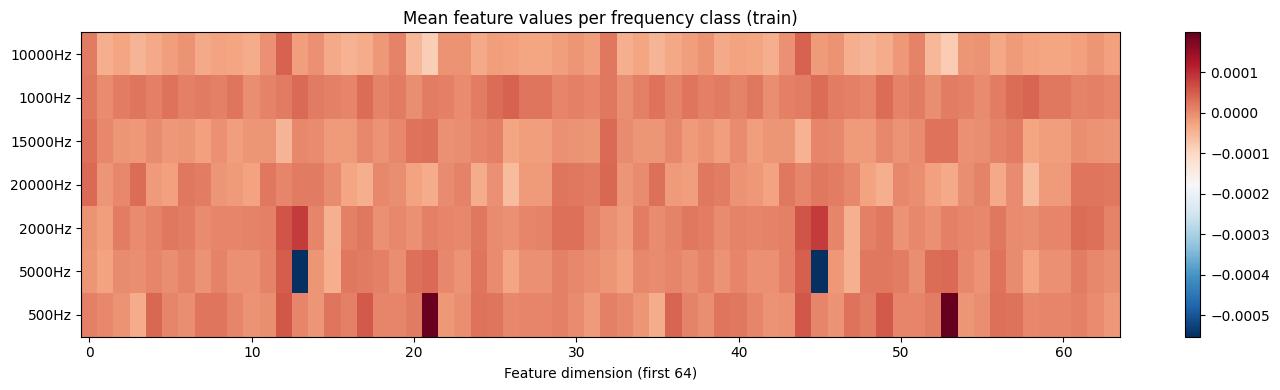

In [10]:
class_means = np.array(
    [X_train[y_train_enc == c].mean(axis=0) for c in range(len(le.classes_))]
)
short_labels = [l.replace("stim_", "") for l in le.classes_]

if X_train.shape[1] <= 32:
    # show raw feature means per channel (works for "mean" mode)
    fig, ax = plt.subplots(figsize=(12, 4))
    for i, label in enumerate(short_labels):
        ax.plot(class_means[i], label=label, alpha=0.8, linewidth=1.5)
    ax.set_xlabel("Channel index")
    ax.set_ylabel("Mean feature value")
    ax.set_title("Per-channel mean features per frequency class (train)")
    ax.legend(ncol=4)
else:
    # too many features to line-plot; show a heatmap of class means (first 64 dims)
    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(class_means[:, :64], aspect="auto", cmap="RdBu_r")
    ax.set_yticks(range(len(short_labels)))
    ax.set_yticklabels(short_labels)
    ax.set_xlabel("Feature dimension (first 64)")
    ax.set_title("Mean feature values per frequency class (train)")
    fig.colorbar(im, ax=ax)

fig.tight_layout()
plt.show()

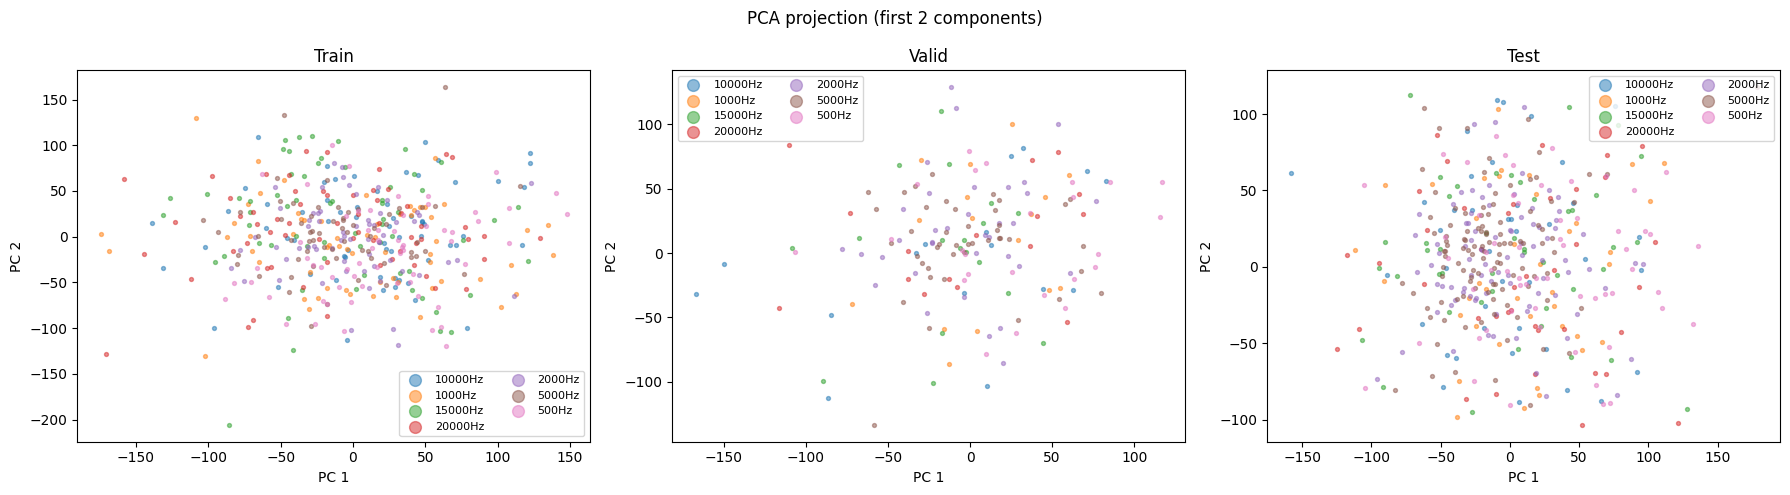

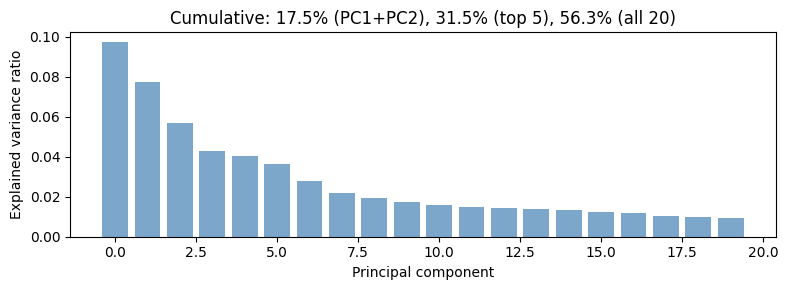

In [11]:
scaler = StandardScaler().fit(X_train)
pca = PCA(n_components=min(20, X_train.shape[1])).fit(scaler.transform(X_train))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, X, y_enc, title in [
    (axes[0], X_train, y_train_enc, "Train"),
    (axes[1], X_valid, y_valid_enc, "Valid"),
    (axes[2], X_test, y_test_enc, "Test"),
]:
    Z = pca.transform(scaler.transform(X))
    for c, label in enumerate(short_labels):
        mask = y_enc == c
        ax.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.5, label=label)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_title(title)
    ax.legend(markerscale=3, fontsize=8, ncol=2)

fig.suptitle("PCA projection (first 2 components)")
fig.tight_layout()
plt.show()

explained = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(explained)), explained, color="steelblue", alpha=0.7)
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title(
    f"Cumulative: {explained[:2].sum():.1%} (PC1+PC2), "
    f"{explained[:5].sum():.1%} (top 5), "
    f"{explained.sum():.1%} (all {len(explained)})"
)
fig.tight_layout()
plt.show()

In [12]:
clf = LogisticRegression(max_iter=100000)
clf.fit(X_train, y_train_enc)

val_acc = accuracy_score(y_valid_enc, clf.predict(X_valid))
test_acc = accuracy_score(y_test_enc, clf.predict(X_test))

print(f"Validation accuracy: {val_acc:.3f}")
print(f"Test accuracy:       {test_acc:.3f}")
print()
print(
    classification_report(
        y_test_enc,
        clf.predict(X_test),
        target_names=short_labels,
    )
)

Validation accuracy: 0.292
Test accuracy:       0.262

              precision    recall  f1-score   support

     10000Hz       0.14      0.25      0.18        40
      1000Hz       0.26      0.15      0.19        39
     15000Hz       0.22      0.24      0.23        45
     20000Hz       0.08      0.15      0.10        40
      2000Hz       0.37      0.19      0.25        88
      5000Hz       0.63      0.29      0.40       109
       500Hz       0.28      0.47      0.35        59

    accuracy                           0.26       420
   macro avg       0.28      0.25      0.24       420
weighted avg       0.35      0.26      0.28       420



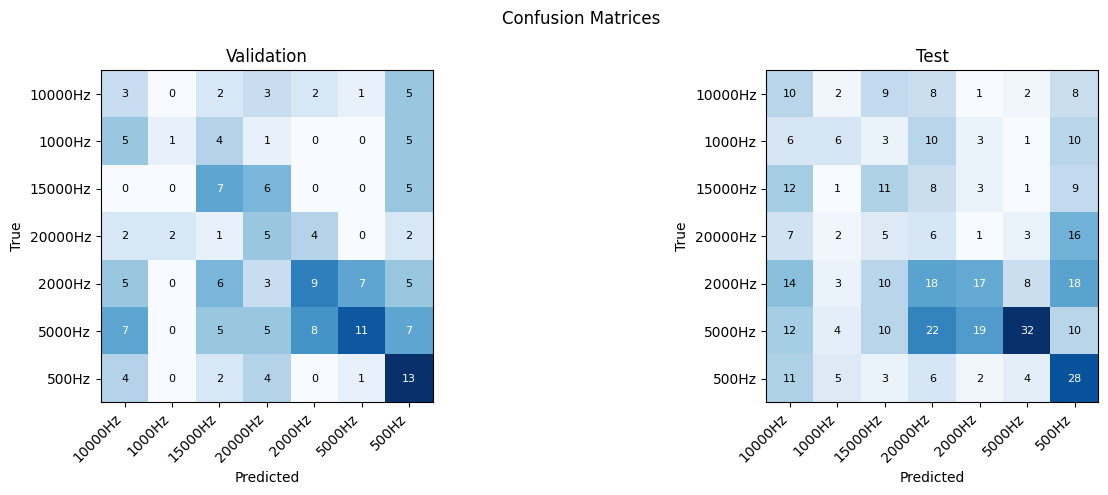

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_valid_enc, clf.predict(X_valid), "Validation"),
    (axes[1], y_test_enc, clf.predict(X_test), "Test"),
]:
    cm = confusion_matrix(y_true, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(short_labels)))
    ax.set_yticks(range(len(short_labels)))
    ax.set_xticklabels(short_labels, rotation=45, ha="right")
    ax.set_yticklabels(short_labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=8)

fig.suptitle("Confusion Matrices")
fig.tight_layout()
plt.show()